In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

### Beta Distribution

The **Beta distribution** models the probability of a probability. It represents our uncertainty about the true success probability $p$ of a Bernoulli distribution.

The probability density function (PDF) is given by:

$$
f(p; \alpha, \beta) = \frac{p^{\alpha-1}(1-p)^{\beta-1}}{B(\alpha, \beta)}
$$

where:
- $\alpha > 0$ and $\beta > 0$ are shape parameters
- $B(\alpha, \beta)$ is the beta function, serving as a normalizing constant

#### Key Properties:
- **Mean**: $\frac{\alpha}{\alpha + \beta}$
- **Mode**: $\frac{\alpha - 1}{\alpha + \beta - 2}$ for $\alpha, \beta > 1$
- **Variance**: $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$

#### Intuition:
- $\alpha$ can be interpreted as **prior successes** + 1
- $\beta$ can be interpreted as **prior failures** + 1
- The distribution is **conjugate prior** to the Bernoulli/binomial likelihood

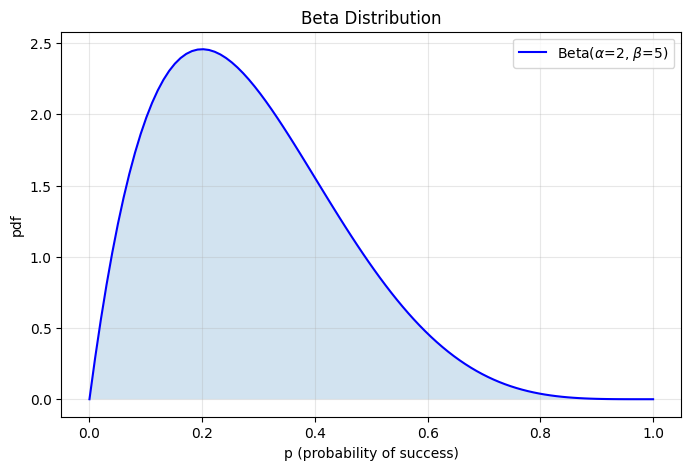

In [6]:
#  parameters
alpha, beta_params = 2, 5
x = np.linspace(0, 1, 100)
y = beta.pdf(x, alpha, beta_params)

# plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'b-', label=f'Beta($\\alpha$={alpha}, $\\beta$={beta_params})')
plt.fill_between(x, y, alpha=0.2)
plt.xlabel('p (probability of success)')
plt.ylabel('pdf')
plt.title('Beta Distribution')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### When to Use the Beta Distribution

The Beta distribution is particularly useful in the following scenarios:

- **Modeling uncertainty** about a proportion or percentage
- **Bayesian updating** with binomial data
- **A/B testing** and conversion rate analysis
- **Prior distributions** for binomial proportions

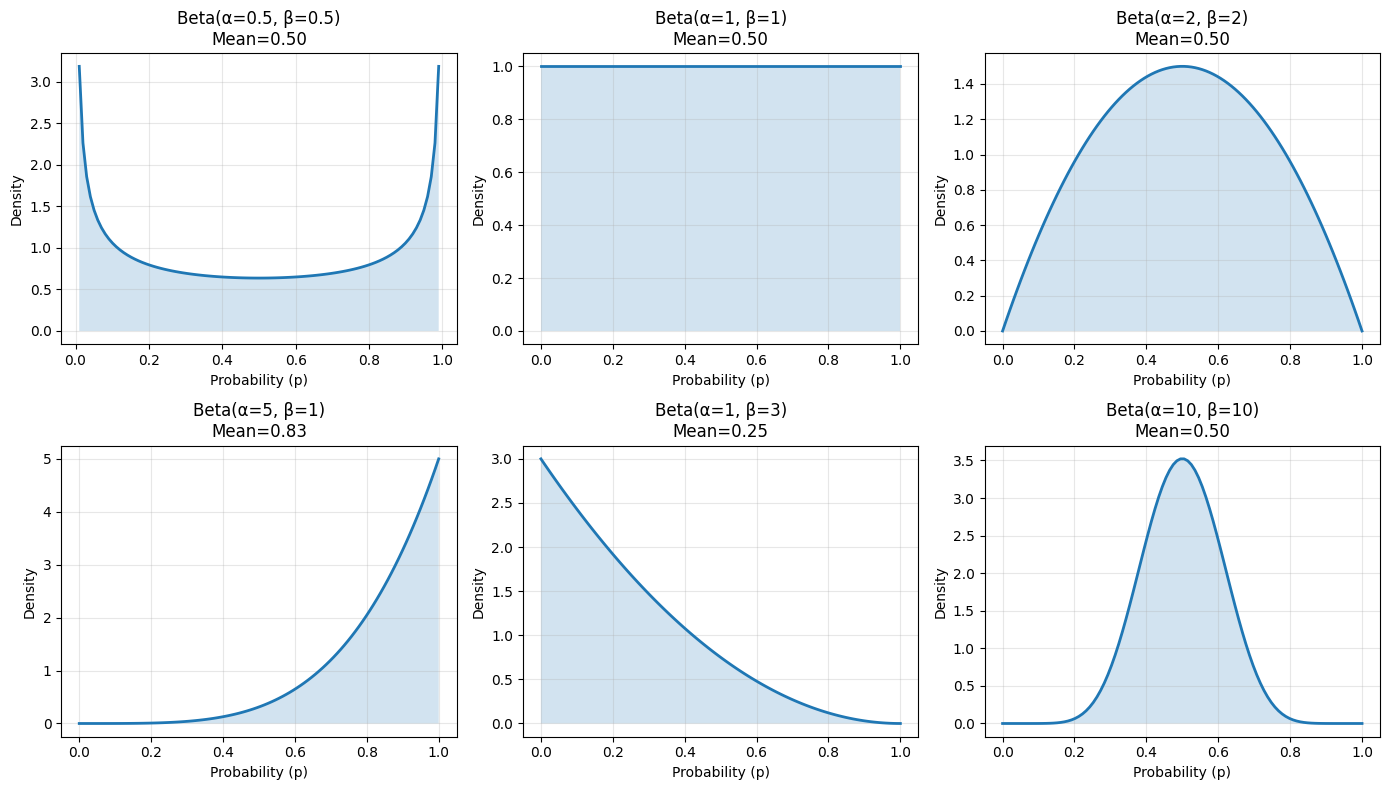

In [9]:
# shapes
alpha_beta = [
    (0.5, 0.5),  # U-shaped (extreme probabilities)
    (1, 1),      # Uniform (no prior info)
    (2, 2),      # Bell-shaped centered at 0.5
    (5, 1),      # Skewed toward 1 (mostly successes)
    (1, 3),      # Skewed toward 0 (mostly failures)
    (10, 10),    # Narrow bell at 0.5 (lots of evidence)
]

plt.figure(figsize=(14, 8))

for i, (alpha, beta_param) in enumerate(alpha_beta, 1):
    x = np.linspace(0, 1, 100)
    pdf = beta.pdf(x, alpha, beta_param)
    
    plt.subplot(2, 3, i)
    plt.plot(x, pdf, linewidth=2)
    plt.fill_between(x, pdf, alpha=0.2)
    plt.title(f'Beta(α={alpha}, β={beta_param})\nMean={alpha/(alpha+beta_param):.2f}')
    plt.xlabel('Probability (p)')
    plt.ylabel('Density')
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Bayesian A/B Testing

### A/B Testing with Beta-Binomial Model

**Setup:**
- Version A: 120 conversions / 1000 visitors
- Version B: 150 conversions / 1000 visitors

**Prior:** Beta(1,1) → Uniform (no prior knowledge)

**Posterior Update:**
- A: Beta(1+120, 1+880) = Beta(121, 881)
- B: Beta(1+150, 1+850) = Beta(151, 851)

The **"+ 1"** represents the prior parameters of **Beta(1, 1)**. You're adding:

- **1 success** (the $\alpha$ from the prior)
- **1 failure** (the $\beta$ from the prior)

This is equivalent to starting with **2 virtual observations** (1 success, 1 failure) before seeing any real data, which makes the uniform prior proper and mathematically convenient! 🎯

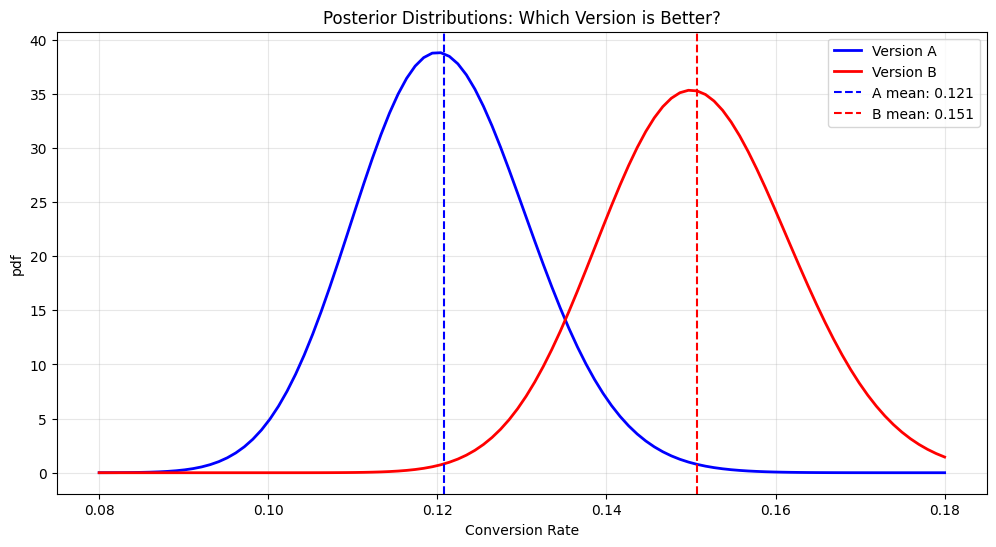

In [13]:
# A/B Test Example
# Version A: 120 conversions out of 1000 visitors
# Version B: 150 conversions out of 1000 visitors

# Prior: Beta(1,1) = Uniform (no prior knowledge)
# Posterior = Beta(α + k, β + n - k)
# k = number of successes
# n = number of trials
# n - k = number of failures
a_alpha, a_beta = 1 + 120, 1 + (1000 - 120)  # Beta(121, 881)
b_alpha, b_beta = 1 + 150, 1 + (1000 - 150)  # Beta(151, 851)

# posterior distributions
x = np.linspace(0.08, 0.18, 100)
a_pdf = beta.pdf(x, a_alpha, a_beta)
b_pdf = beta.pdf(x, b_alpha, b_beta)

plt.figure(figsize=(12, 6))

plt.plot(x, a_pdf, 'b-', linewidth=2, label='Version A')
plt.plot(x, b_pdf, 'r-', linewidth=2, label='Version B')
plt.axvline(a_alpha/(a_alpha+a_beta), color='b', linestyle='--', label=f'A mean: {a_alpha/(a_alpha+a_beta):.3f}')
plt.axvline(b_alpha/(b_alpha+b_beta), color='r', linestyle='--', label=f'B mean: {b_alpha/(b_alpha+b_beta):.3f}')

plt.title('Posterior Distributions: Which Version is Better?')
plt.xlabel('Conversion Rate')
plt.ylabel('pdf')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
# Probability B is better than A
# rvs stands for Random Variate Sampling. It generates random samples from a probability distribution.
# draws 100,000 random samples from each Beta distribution
a_samples = beta.rvs(a_alpha, a_beta, size=100000)
b_samples = beta.rvs(b_alpha, b_beta, size=100000)

prob_b_better = np.mean(b_samples > a_samples)
print(f"Probability Version B has higher conversion rate: {prob_b_better:.2%}")

# Credible interval for B
# ppf = percent point function (inverse CDF)
b_ci_lower = beta.ppf(0.025, b_alpha, b_beta)
b_ci_upper = beta.ppf(0.975, b_alpha, b_beta)
print(f"95% Credible Interval for B: [{b_ci_lower:.2%}, {b_ci_upper:.2%}]")

Probability Version B has higher conversion rate: 97.50%
95% Credible Interval for B: [12.92%, 17.35%]


### Are we generating fake data with `rvs(size=100000)`?

**No!** We're not generating fake data. We're **simulating the posterior distribution** to approximate probabilities.


### What's really happening:

**Real data (observed):**
- Version A: 120 conversions / 1000 visitors
- Version B: 150 conversions / 1000 visitors

**We already have the posterior distribution:** Beta(151, 851)

**`rvs()` does:** Draws random samples FROM this known distribution


### What does [12.92%, 17.35%] mean?

This is the **95% Credible Interval** for Version B's true conversion rate.

**Interpretation:**
Given the data and our prior, there is a **95% probability** that Version B's true conversion rate lies between **12.92%** and **17.35%**.

**In plain English:**
- We're 95% confident B's conversion rate is somewhere in this range
- Only 2.5% chance it's below 12.92%
- Only 2.5% chance it's above 17.35%

**Visual Representation:**

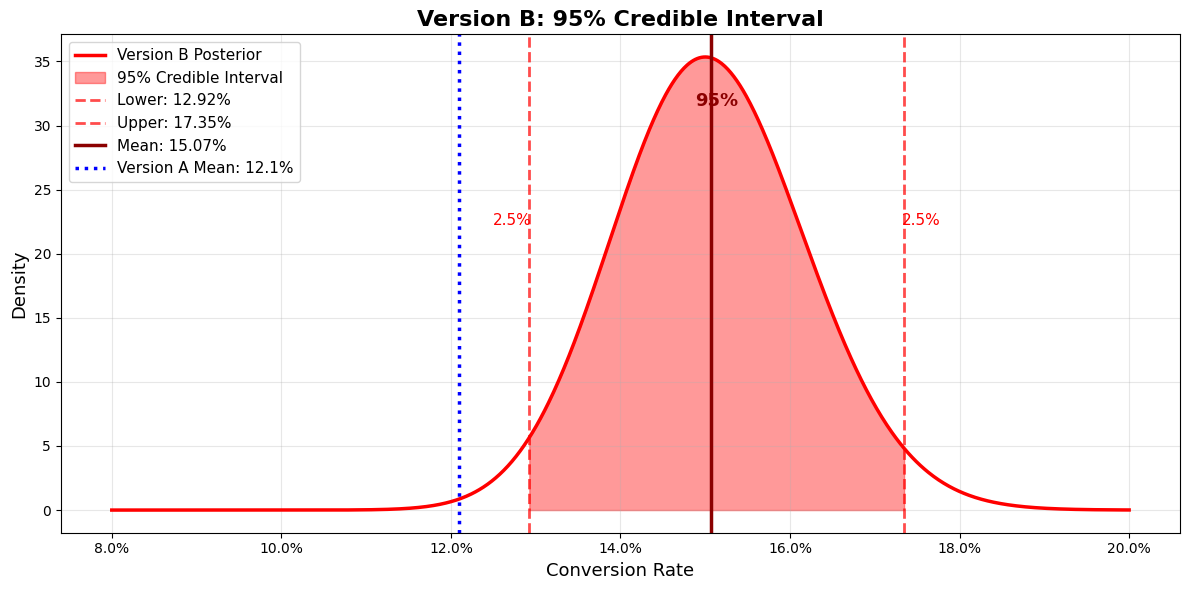

In [17]:
# Parameters for Version B
b_alpha, b_beta = 151, 851
x = np.linspace(0.08, 0.20, 1000)
b_pdf = beta.pdf(x, b_alpha, b_beta)

# Credible interval bounds
ci_lower, ci_upper = 0.1292, 0.1735
mean_b = b_alpha / (b_alpha + b_beta)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot full distribution
ax.plot(x, b_pdf, 'r-', linewidth=2.5, label='Version B Posterior')

# Shade 95% credible interval
x_ci = x[(x >= ci_lower) & (x <= ci_upper)]
y_ci = b_pdf[(x >= ci_lower) & (x <= ci_upper)]
ax.fill_between(x_ci, 0, y_ci, alpha=0.4, color='red', label='95% Credible Interval')

# Add vertical lines
ax.axvline(ci_lower, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Lower: {ci_lower:.2%}')
ax.axvline(ci_upper, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Upper: {ci_upper:.2%}')
ax.axvline(mean_b, color='darkred', linestyle='-', linewidth=2.5, label=f'Mean: {mean_b:.2%}')

# Add Version A mean for comparison
ax.axvline(0.121, color='blue', linestyle=':', linewidth=2.5, label='Version A Mean: 12.1%')

# Add annotations
ax.text(ci_lower - 0.002, ax.get_ylim()[1]*0.6, '2.5%', ha='center', fontsize=11, color='red')
ax.text(ci_upper + 0.002, ax.get_ylim()[1]*0.6, '2.5%', ha='center', fontsize=11, color='red')
ax.text((ci_lower + ci_upper)/2, ax.get_ylim()[1]*0.85, '95%', ha='center', fontsize=13, fontweight='bold', color='darkred')

# Labels and title
ax.set_title('Version B: 95% Credible Interval', fontsize=16, fontweight='bold')
ax.set_xlabel('Conversion Rate', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.legend(loc='upper left', fontsize=11)
ax.grid(alpha=0.3)

# Format x-axis as percentages
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1%}'))

plt.tight_layout()
plt.show()

### When to Use the Beta Distribution

| Use Case | Example |
|----------|---------|
| **A/B Testing** | "Which version has higher conversion rate?" |
| **Bayesian Inference** | "What's the probability distribution of the CTR?" |
| **Thompson Sampling** | "Which ad should we show next?" |
| **Uncertainty Quantification** | "How confident are we about this prediction?" |
| **Model Calibration** | "Are our predicted probabilities accurate?" |